In [1]:
# Import libraries
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load dataset
data = load_breast_cancer()

# Put into DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Preview dataset
print(df.shape)
df.head()


(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


<class 'numpy.ndarray'>
(569, 31)


In [3]:
from sklearn.model_selection import train_test_split

# Split the data into features (X) and target (y)
X = df_np[:, :-1]
y = df_np[:, -1]

# Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting arrays to verify the split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


In [5]:
# Filter X_train based on y_train where y_train is 1
X_train_filtered = X_train[y_train == 1]

# Print the shape of the filtered X_train to verify
print("Shape of filtered X_train:", X_train_filtered.shape)

Shape of filtered X_train: (286, 30)


In [6]:
from sklearn.neighbors import KDTree

# Create a KD-tree from the filtered training data
kdtree = KDTree(X_train_filtered)

# Print a confirmation message
print("KD-tree created successfully.")

KD-tree created successfully.


In [7]:
closeness_param = 1

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

# Initialize an empty list to store cosine similarities
cosine_similarities = []

# Iterate over each vector in X_train_filtered
for i in range(X_train_filtered.shape[0]):
    # Iterate over every other vector in X_train_filtered
    for j in range(X_train_filtered.shape[0]):
        # Calculate the cosine similarity between the two vectors
        # Reshape the vectors to be 2D arrays as required by cosine_similarity
        similarity = cosine_similarity(X_train_filtered[i].reshape(1, -1), X_train_filtered[j].reshape(1, -1))[0][0]
        # Append the similarity to the list
        cosine_similarities.append(similarity)

# You can print the first few values or the length of the list to verify
print("Number of cosine similarity calculations:", len(cosine_similarities))
# print("First 10 cosine similarities:", cosine_similarities[:10]) # Uncomment to see the first few

Number of cosine similarity calculations: 81796


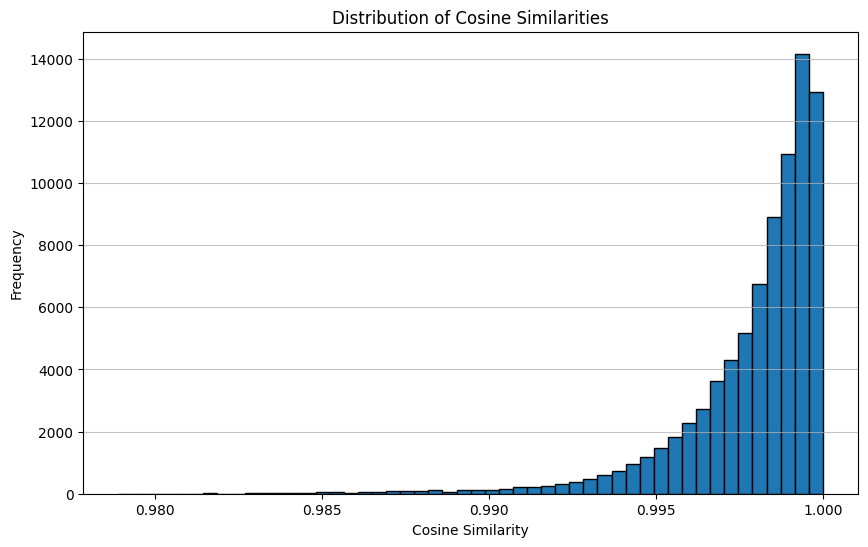

In [9]:
import matplotlib.pyplot as plt

# Create a histogram of the cosine similarities
plt.figure(figsize=(10, 6))
plt.hist(cosine_similarities, bins=50, edgecolor='black')  # You can adjust the number of bins
plt.title('Distribution of Cosine Similarities')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

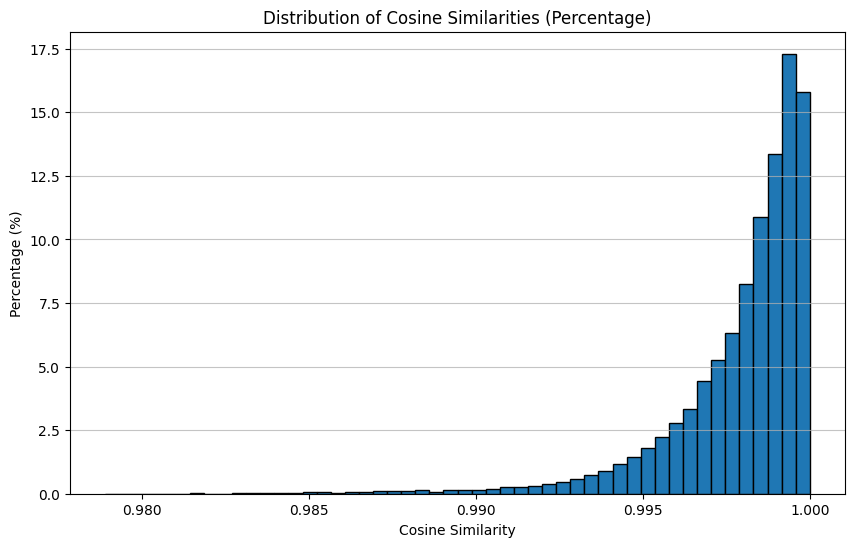

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Create a histogram of the cosine similarities
plt.figure(figsize=(10, 6))

# Calculate the counts and bin edges
counts, bin_edges = np.histogram(cosine_similarities, bins=50)

# Calculate the percentages
percentages = (counts / len(cosine_similarities)) * 100

# Plot the histogram with percentages on the y-axis
plt.bar(bin_edges[:-1], percentages, width=np.diff(bin_edges), edgecolor='black', align='edge')

plt.title('Distribution of Cosine Similarities (Percentage)')
plt.xlabel('Cosine Similarity')
plt.ylabel('Percentage (%)')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [11]:
import numpy as np

# Calculate the 80th percentile of the cosine similarities
top_20_percentile = np.percentile(cosine_similarities, 80)

# Print the threshold for the top 20%
print(f"The cosine similarity score for the top 20% is: {top_20_percentile}")

The cosine similarity score for the top 20% is: 0.9994870474947484


In [14]:
# Initialize an empty list to store pairs of vectors with high cosine similarity
highly_similar_vectors = []

# Iterate over each vector in X_train_filtered
for i in range(X_train_filtered.shape[0]):
    # Iterate over every other vector in X_train_filtered
    for j in range(X_train_filtered.shape[0]):
        # Calculate the cosine similarity between the two vectors
        similarity = cosine_similarity(X_train_filtered[i].reshape(1, -1), X_train_filtered[j].reshape(1, -1))[0][0]

        # Check if the similarity is above the top 20th percentile and the vectors are not the same
        if similarity > top_20_percentile and i != j:
            # Store the indices of the pair of vectors as a tuple
            highly_similar_vectors.append((i, j))

# Print the number of highly similar vector pairs found
print(f"Number of highly similar vector pairs (above {top_20_percentile:.4f}): {len(highly_similar_vectors)}")

# You can print the first few pairs to verify
print("First 5 highly similar vector pairs (indices):", highly_similar_vectors[:5])

Number of highly similar vector pairs (above 0.9995): 16072
First 5 highly similar vector pairs (indices): [(0, 8), (0, 29), (0, 35), (0, 93), (0, 124)]


Number of nodes in the graph: 281
Number of edges in the graph: 8036


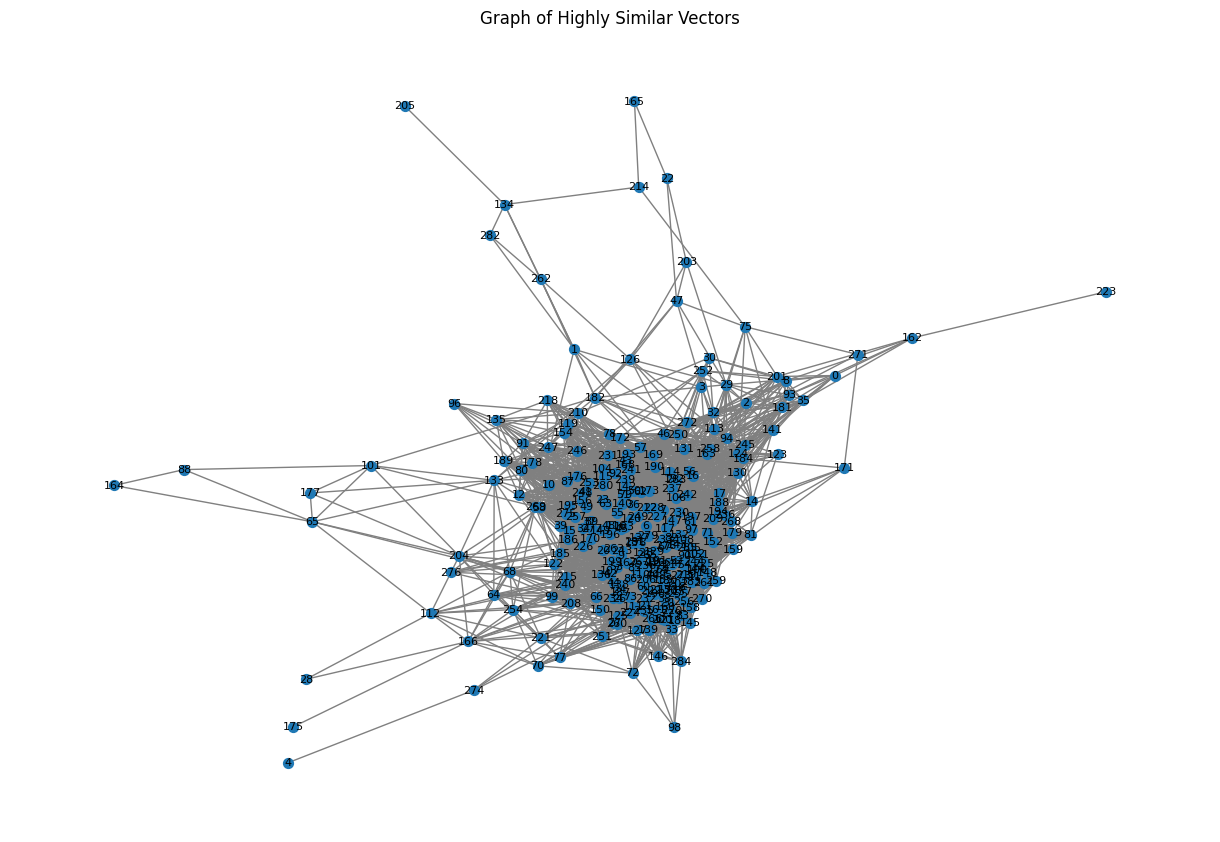

In [22]:
import networkx as nx
import matplotlib.pyplot as plt

# Create an empty graph
G = nx.Graph()

# Add nodes and edges to the graph
for i, j in highly_similar_vectors:
    # Add nodes (if they don't exist)
    G.add_node(i)
    G.add_node(j)
    # Add edge between the nodes
    G.add_edge(i, j)

# Print information about the created graph
print(f"Number of nodes in the graph: {G.number_of_nodes()}")
print(f"Number of edges in the graph: {G.number_of_edges()}")

# Visualize the graph
plt.figure(figsize=(12, 8))
nx.draw(G, with_labels=True, node_size=50, font_size=8, edge_color='gray')
plt.title('Graph of Highly Similar Vectors')
plt.show()

In [18]:
# Find all maximal cliques in the graph
cliques = list(nx.find_cliques(G))

# Print the number of cliques
print(f"Number of cliques in the graph: {len(cliques)}")

Number of cliques in the graph: 5637


In [20]:
# Find all maximal cliques in the graph
all_cliques = list(nx.find_cliques(G))

# Filter for cliques containing node 1
cliques_with_node_1 = [clique for clique in all_cliques if 1 in clique]

# Print the cliques containing node 1
print(f"Cliques containing node 1: {cliques_with_node_1}")

Cliques containing node 1: [[1, 282, 134, 262], [1, 3], [1, 182, 242, 258], [1, 182, 242, 269], [1, 182, 262]]


In [21]:
# Find the number of connected components in the graph
num_connected_components = nx.number_connected_components(G)

# Print the number of connected components
print(f"Number of connected components in the graph: {num_connected_components}")

Number of connected components in the graph: 1


In [23]:
import numpy as np

def is_on_line_segment(a, b, c, threshold=1e-6):
    """
    Checks if point c lies on the line segment defined by points a and b.

    Args:
        a (np.ndarray): The starting point of the line segment.
        b (np.ndarray): The ending point of the line segment.
        c (np.ndarray): The point to check.
        threshold (float): The tolerance for checking if c is on the line.

    Returns:
        bool: True if c lies on the line segment a-b within the threshold, False otherwise.
    """
    # Check for collinearity using the cross product (only for 2D/3D vectors)
    # For higher dimensions, check if the vector c-a is parallel to b-a
    if np.linalg.norm(b - a) == 0: # Handle the case where a and b are the same point
        return np.linalg.norm(c - a) < threshold

    # Check if the vectors (c-a) and (b-a) are parallel
    # This is equivalent to checking if the projection of (c-a) onto (b-a) is equal to (c-a)
    # Or, check if the angle between (c-a) and (b-a) is close to 0 or 180 degrees
    dot_product = np.dot(c - a, b - a)
    norm_product = np.linalg.norm(c - a) * np.linalg.norm(b - a)

    # Avoid division by zero
    if norm_product == 0:
        return np.linalg.norm(c - a) < threshold # c must be very close to a (which is the same as b)


    cosine_angle = dot_product / norm_product

    # Check if the angle is close to 0 or 180 degrees (collinear)
    if not np.isclose(abs(cosine_angle), 1.0, atol=threshold):
        return False

    # Check if c lies between a and b
    # This can be done by checking if the dot product of (c-a) and (c-b) is negative or zero
    # If c is on the line segment, then (c-a) and (c-b) will point in opposite directions
    dot_product_check = np.dot(c - a, c - b)
    return dot_product_check <= threshold # Use threshold to handle floating point comparisons

In [24]:
# Filter X_test for instances where y_test is 0
X_test_filtered_0 = X_test[y_test == 0]

# Filter X_test for instances where y_test is 1
X_test_filtered_1 = X_test[y_test == 1]

# Print the shapes of the filtered arrays to verify
print("Shape of X_test_filtered_0:", X_test_filtered_0.shape)
print("Shape of X_test_filtered_1:", X_test_filtered_1.shape)

Shape of X_test_filtered_0: (43, 30)
Shape of X_test_filtered_1: (71, 30)


In [35]:
# Initialize lists to store results
is_on_graph_line = []
is_NOT_on_graph_line = []

# Iterate over every vector in X_test_filtered_1
for test_vector in X_test_filtered_1:
    # Find the vector in X_train_filtered that has the biggest dot product
    dot_products = np.dot(X_train_filtered, test_vector)
    most_similar_train_index = np.argmax(dot_products)

    # Find the node in the graph according to the row
    # The node index in the graph corresponds to the row index in X_train_filtered
    graph_node = most_similar_train_index

    # Find all the edges that node has
    # Get the neighbors of the node in the graph
    neighbors = list(G.neighbors(graph_node))

    # Flag to check if the test vector is on any line segment
    on_a_line = False

    # Iterate over the neighbors (forming edges with the graph_node)
    for neighbor_node in neighbors:
        # Get the vectors from X_train_filtered corresponding to the edge
        vector_a = X_train_filtered[graph_node]
        vector_b = X_train_filtered[neighbor_node]

        # Use the is_on_line_segment function to check if the test vector is on the line segment
        if is_on_line_segment(vector_a, vector_b, test_vector, threshold=1): # Using the default threshold
            on_a_line = True
            break # If it's on one line, no need to check others for this test vector

    # Store the test vector in the appropriate list
    if on_a_line:
        is_on_graph_line.append(test_vector)
    else:
        is_NOT_on_graph_line.append(test_vector)

# Print the number of vectors in each list
print(f"Number of vectors on a graph line: {len(is_on_graph_line)}")
print(f"Number of vectors NOT on a graph line: {len(is_NOT_on_graph_line)}")

Number of vectors on a graph line: 8
Number of vectors NOT on a graph line: 63


In [36]:
import numpy as np

def is_in_span(X, y, rel_tol=1e-10):
    """
    Return True iff y is (numerically) in the span of the columns of X.

    Args:
        X (ndarray): shape (n, k) matrix with x-vectors as columns.
        y (ndarray): shape (n,) target vector.
        rel_tol (float): relative tolerance for the residual test.

    Notes:
        Uses SVD to get a rank-revealed basis U_r of col(X),
        then checks ||y - U_r (U_r^T y)|| <= rel_tol * ||y||.
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    n = X.shape[0]
    if y.shape[0] != n:
        raise ValueError(f"Dimension mismatch: X has {n} rows, y has {y.shape[0]} entries.")

    # Edge cases
    if X.size == 0:
        return np.linalg.norm(y) <= rel_tol * max(1.0, np.linalg.norm(y))

    # SVD
    U, s, Vt = np.linalg.svd(X, full_matrices=False)

    # Numerical rank threshold (standard choice)
    eps = np.finfo(float).eps
    tol = s.max() * max(X.shape) * eps if s.size else 0.0
    r_mask = s > tol

    if not np.any(r_mask):  # X is (numerically) all-zero columns
        return np.linalg.norm(y) <= rel_tol * max(1.0, np.linalg.norm(y))

    Ur = U[:, r_mask]

    # Project y onto col(X) and measure residual
    y_proj = Ur @ (Ur.T @ y)
    resid = np.linalg.norm(y - y_proj)
    return resid <= rel_tol * max(1.0, np.linalg.norm(y))

In [37]:
def cliques_with_node(G, node):
    """
    Return all maximal cliques in graph G that contain the given node.

    Args:
        G (networkx.Graph): The input graph.
        node (hashable): Node identifier (must exist in G).

    Returns:
        list of lists: Each inner list is a clique containing the node.
    """
    all_cliques = nx.find_cliques(G)
    return [clique for clique in all_cliques if node in clique]

In [42]:
# Initialize lists to store results
is_in_clique_span = []
is_NOT_in_clique_span = []

# Iterate over every vector in X_test_filtered_1
for test_vector in X_test_filtered_1:
    # Find the vector in X_train_filtered that has the biggest dot product
    dot_products = np.dot(X_train_filtered, test_vector)
    most_similar_train_index = np.argmax(dot_products)

    # Find the node in the graph according to the row
    graph_node = most_similar_train_index

    # Find all cliques that the graph_node is part of
    cliques = cliques_with_node(G, graph_node)

    # Flag to check if the test vector is in the span of any clique
    in_a_clique_span = False

    # Iterate over the cliques containing the graph_node
    for clique in cliques:
        # Create a 2D array with vectors from X_train_filtered corresponding to the nodes in the clique
        clique_vectors = np.array([X_train_filtered[node] for node in clique])

        # Use the is_in_span function to check if the test vector is in the span of the clique vectors
        if is_in_span(clique_vectors.T, test_vector, rel_tol=0.001): # is_in_span expects column vectors, so transpose clique_vectors
            in_a_clique_span = True
            break # If it's in the span of one clique, no need to check others for this test vector

    # Store the test vector in the appropriate list
    if in_a_clique_span:
        is_in_clique_span.append(test_vector)
    else:
        is_NOT_in_clique_span.append(test_vector)

# Print the number of vectors in each list
print(f"Number of vectors in a clique span: {len(is_in_clique_span)}")
print(f"Number of vectors NOT in a clique span: {len(is_NOT_in_clique_span)}")

Number of vectors in a clique span: 37
Number of vectors NOT in a clique span: 34


In [43]:
# Initialize lists to store results for X_test_filtered_0
is_in_clique_span_0 = []
is_NOT_in_clique_span_0 = []

# Iterate over every vector in X_test_filtered_0
for test_vector in X_test_filtered_0:
    # Find the vector in X_train_filtered that has the biggest dot product
    dot_products = np.dot(X_train_filtered, test_vector)
    most_similar_train_index = np.argmax(dot_products)

    # Find the node in the graph according to the row
    graph_node = most_similar_train_index

    # Find all cliques that the graph_node is part of
    cliques = cliques_with_node(G, graph_node)

    # Flag to check if the test vector is in the span of any clique
    in_a_clique_span = False

    # Iterate over the cliques containing the graph_node
    for clique in cliques:
        # Create a 2D array with vectors from X_train_filtered corresponding to the nodes in the clique
        clique_vectors = np.array([X_train_filtered[node] for node in clique])

        # Use the is_in_span function to check if the test vector is in the span of the clique vectors
        if is_in_span(clique_vectors.T, test_vector, rel_tol=0.001): # is_in_span expects column vectors, so transpose clique_vectors
            in_a_clique_span = True
            break # If it's in the span of one clique, no need to check others for this test vector

    # Store the test vector in the appropriate list
    if in_a_clique_span:
        is_in_clique_span_0.append(test_vector)
    else:
        is_NOT_in_clique_span_0.append(test_vector)

# Print the number of vectors in each list
print(f"Number of vectors in a clique span (X_test_filtered_0): {len(is_in_clique_span_0)}")
print(f"Number of vectors NOT in a clique span (X_test_filtered_0): {len(is_NOT_in_clique_span_0)}")

Number of vectors in a clique span (X_test_filtered_0): 11
Number of vectors NOT in a clique span (X_test_filtered_0): 32
